## Анализ и прогнозирование временных рядов методами искусственного интеллекта

### **Практическая работа 3. Поиск аномалий во временных рядах.**


#### **3.1 Поиск диссонансов с помощью алгоритма HotSAX**

##### 3.1.1 Загрузка и подготовка данных

В данной будет использоваться временной ряд, состоящий из показаний акселерометра. 
Анализируемый временной ряд, описывает две активности человека - бег и шаг.


In [1]:
!pip install scipy
!pip install scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from time import time
import pandas as pd

In [4]:
#fixme: Путь
dataset_dir_path = Path('datasets')
data_path = dataset_dir_path/'walk_run.txt'
walk_run = np.loadtxt(data_path)[3000:4000]
data = walk_run
size_sub = 50

В середине временного ряда происходит смена активности (бег заменяет шаг). Нетипичным поведением, которое мы могли бы назвать диссонансами в данном ряде выступает небольшой участок между активностями, когда человек плавно увеличивает скорость шага до бега. В ходе данной работе наша задача выделить с помощью различных алгоритмов границы нашего диссонанса.

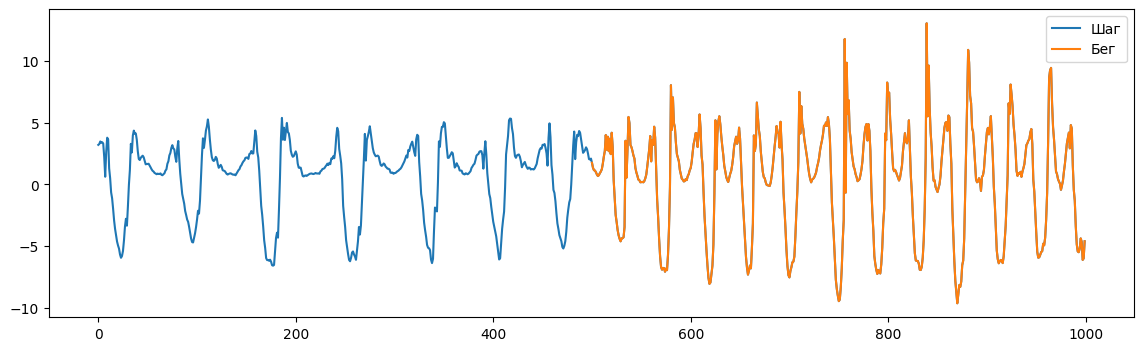

In [5]:
fig, ax =  plt.subplots(figsize=(14,4),ncols=1,nrows=1)
plt.plot(data[:],label='Шаг')
plt.plot(np.arange(data.shape[0]//2,data.shape[0]),data[data.shape[0]//2:],label='Бег')
plt.legend()

In [6]:
result={}
times={}

##### 3.1.2 Реализация полного перебора

Приводится пример кода для нахождения топ 5 диссонансов с помощью реализации полного беребора.
Вам необходимо добавить код для сбора времени обработки данных.

In [10]:
from modules.saxpy.discord import find_discords_brute_force
from time import time

# Замеряем время выполнения
start_brute = time()
# Ищем 5 диссонансов (num_discords=5) длиной 50 (win_size=50)
discords_brute_force = np.stack(find_discords_brute_force(data, 50, 5))
end_brute = time()

time_brute = end_brute - start_brute

# Сохраняем результаты в наши словари
times['brute_force'] = time_brute
result['brute_force'] = discords_brute_force

print(f"Полный перебор занял: {time_brute:.2f} секунд")
print("Найденные диссонансоы (индекс, расстояние):")
print(discords_brute_force)

Полный перебор занял: 91.68 секунд
Найденные диссонансоы (индекс, расстояние):
[[477.           5.88100934]
 [412.           5.32704317]
 [195.           3.39426635]
 [577.           3.35554403]
 [278.           3.10959389]]


##### 3.1.3 HotSAX

Используя [реализацию](https://github.com/seninp/saxpy/blob/master/saxpy/hotsax.py) найдите топ 5 диссонансов ряда.
Произведите замер времени работы.

In [11]:
from modules.saxpy.hotsax import find_discords_hotsax
from time import time

# Замеряем время выполнения
start_hotsax = time()
# Ищем 5 диссонансов (num_discords=5) длиной 50 (win_size=50)
discords_hotsax = np.array(find_discords_hotsax(data, win_size=50, num_discords=5))
end_hotsax = time()

time_hotsax = end_hotsax - start_hotsax

# Сохраняем результаты
times['hotsax'] = time_hotsax
result['hotsax'] = discords_hotsax

print(f"HotSAX занял: {time_hotsax:.2f} секунд")
print("Найденные диссонансы (индекс, расстояние):")
print(discords_hotsax)

HotSAX занял: 2.29 секунд
Найденные диссонансы (индекс, расстояние):
[[477.           5.88100934]
 [412.           5.32704317]
 [195.           3.39426635]
 [577.           3.35554403]
 [278.           3.10959389]]


##### 3.1.4 Визаулизация

Вам необходимо реализовать код позволяющий:
1. Вывести на одном графике ряд и его диссонансы
2. Столбчатую диаграмму времени работы обоих алгоритмов
   
Постройте графики для обоих алгоритмов и сравните полученные результаты.

Пример графика:

![first_graf](pics/fig_ex_1.png)

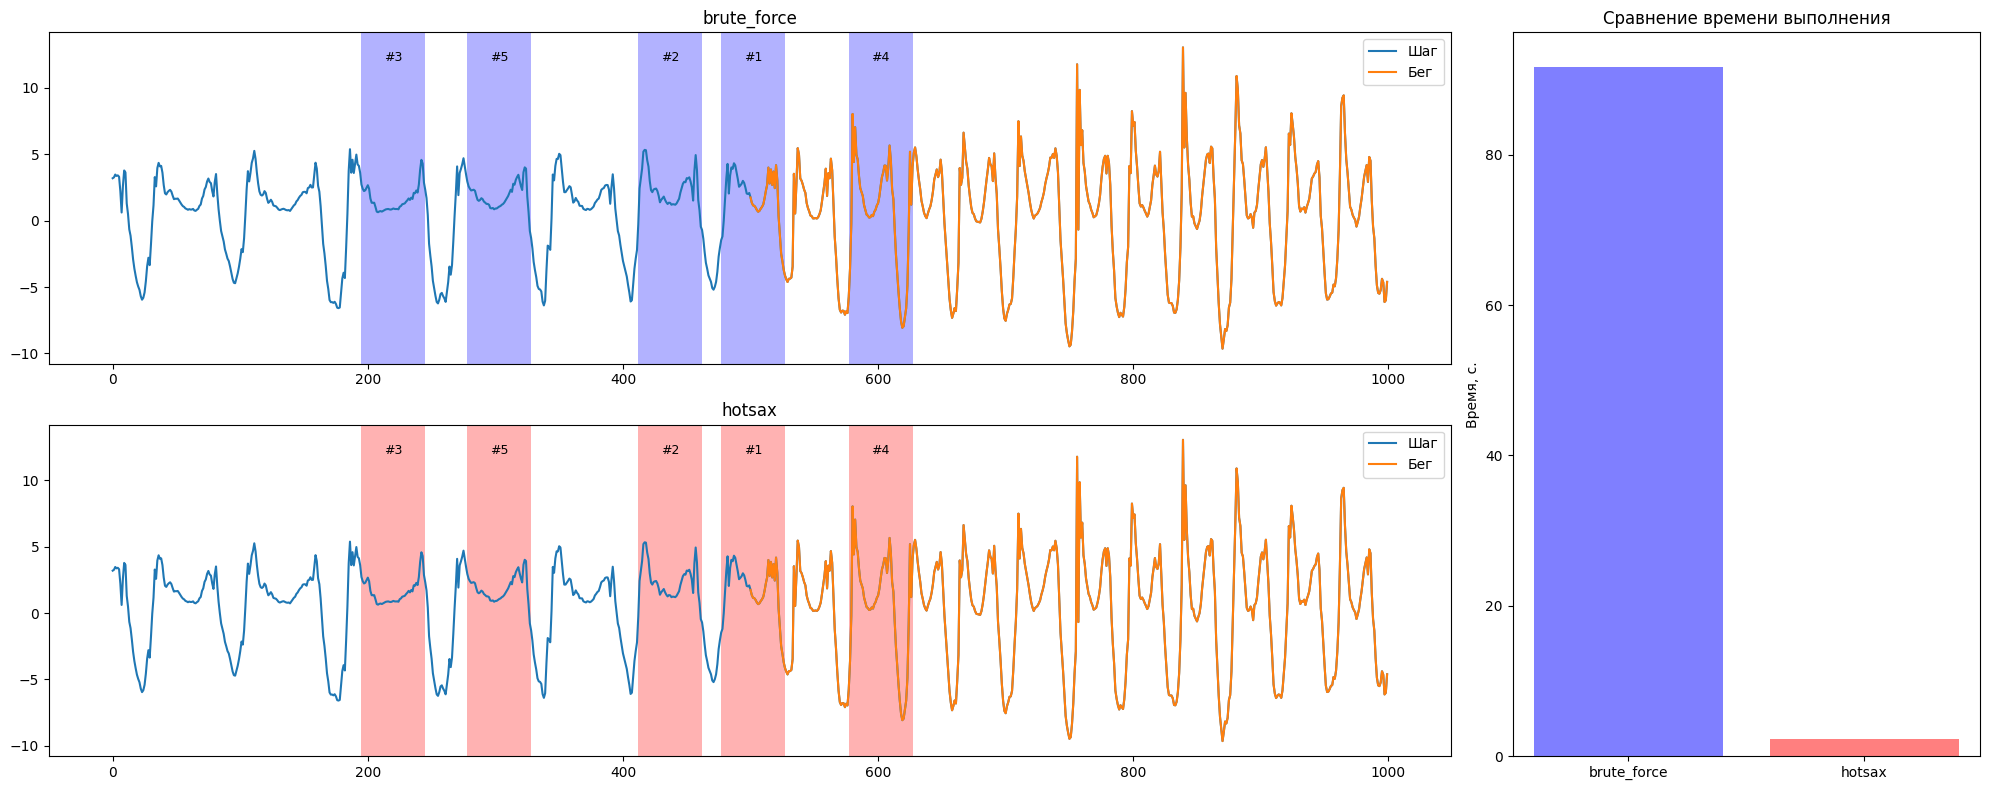

In [12]:
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle

# --- Функция для отрисовки диссонансов на графике ---
def plot_discords(ax, data, discords, title, color):
    # Рисуем основной временной ряд
    ax.plot(data, label='Шаг')
    ax.plot(np.arange(data.shape[0]//2, data.shape[0]), data[data.shape[0]//2:], label='Бег')
    ax.set_title(title)
    
    # Извлекаем только индексы начала диссонансов
    discord_indices = discords[:, 0].astype(int)
    
    # Для каждого диссонанса рисуем полупрозрачный прямоугольник
    for i, idx in enumerate(discord_indices):
        rect = Rectangle((idx, ax.get_ylim()[0]), size_sub, ax.get_ylim()[1] - ax.get_ylim()[0], facecolor=color, alpha=0.3)
        ax.add_patch(rect)
        ax.text(idx + size_sub / 2, ax.get_ylim()[1] * 0.9, f"#{i+1}", ha='center', va='top', fontsize=9)

# --- Создание фигуры и сетки для графиков ---
fig = plt.figure(figsize=(20, 8))
# Сетка: 2 строки, 2 колонки. Левая колонка в 3 раза шире правой.
gs = gridspec.GridSpec(2, 2, width_ratios=[3, 1])

# --- График для Brute Force ---
ax1 = plt.subplot(gs[0, 0])
plot_discords(ax1, data, result['brute_force'], 'brute_force', 'blue')
ax1.legend(['Шаг', 'Бег'])

# --- График для HotSAX ---
ax2 = plt.subplot(gs[1, 0])
plot_discords(ax2, data, result['hotsax'], 'hotsax', 'red')
ax2.legend(['Шаг', 'Бег'])

# --- Гистограмма времени выполнения ---
ax3 = plt.subplot(gs[:, 1]) # Эта гистограмма займет обе строки в правой колонке
algorithms = list(times.keys())
execution_times = list(times.values())
ax3.bar(algorithms, execution_times, color=['blue', 'red'], alpha=0.5)
ax3.set_ylabel('Время, с.')
ax3.set_title('Сравнение времени выполнения')

# Отображаем все графики
plt.tight_layout()
plt.show()

In [13]:
from matplotlib.patches import Rectangle

##### 3.1.5 Такси NY

Произведите поиск диссонансов с помощью обоих алгоритмов на наборе данных, содержащим информацию о среднем числе пассажиров в NY. Отобразите найденные диссонансы обоими алгоритмами. 

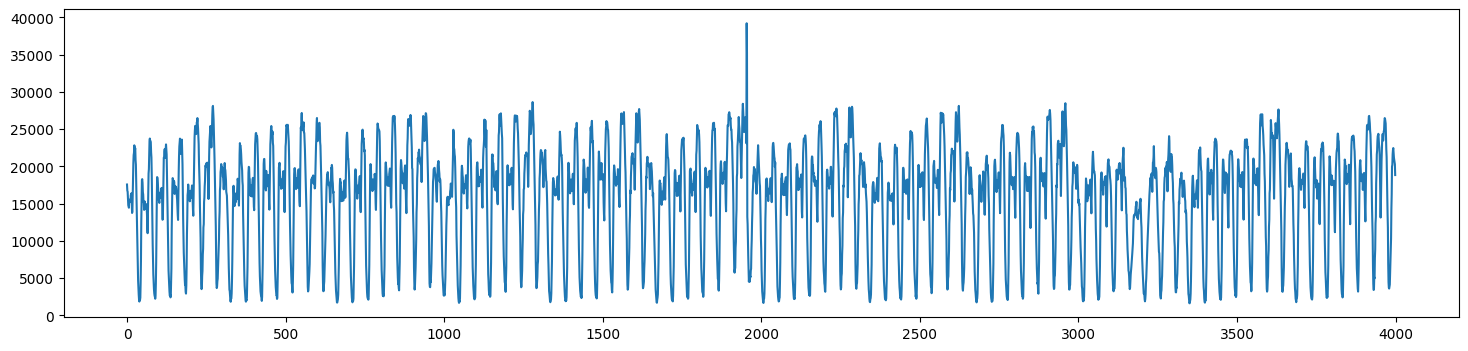

In [15]:
nyc_taxi = pd.read_csv(dataset_dir_path/'nyc_taxi.csv',index_col=0).values[4000:8000,0].astype(np.float64)
fig = plt.figure(figsize=(18, 4))
plt.plot(nyc_taxi)

Запускаю HotSAX для данных о такси...
HotSAX занял: 3.39 секунд
Найденные диссонансы (HotSAX):
[[1.95300000e+03 3.52251123e+00]
 [3.12100000e+03 2.98229466e+00]
 [3.18500000e+03 2.56613115e+00]]

Запускаю полный перебор для данных о такси... Это может занять много времени.
Полный перебор занял: 1248.22 секунд
Найденные диссонансы (Brute Force):
[[1.95300000e+03 3.52251123e+00]
 [3.12100000e+03 2.98229466e+00]
 [3.18500000e+03 2.56613115e+00]]


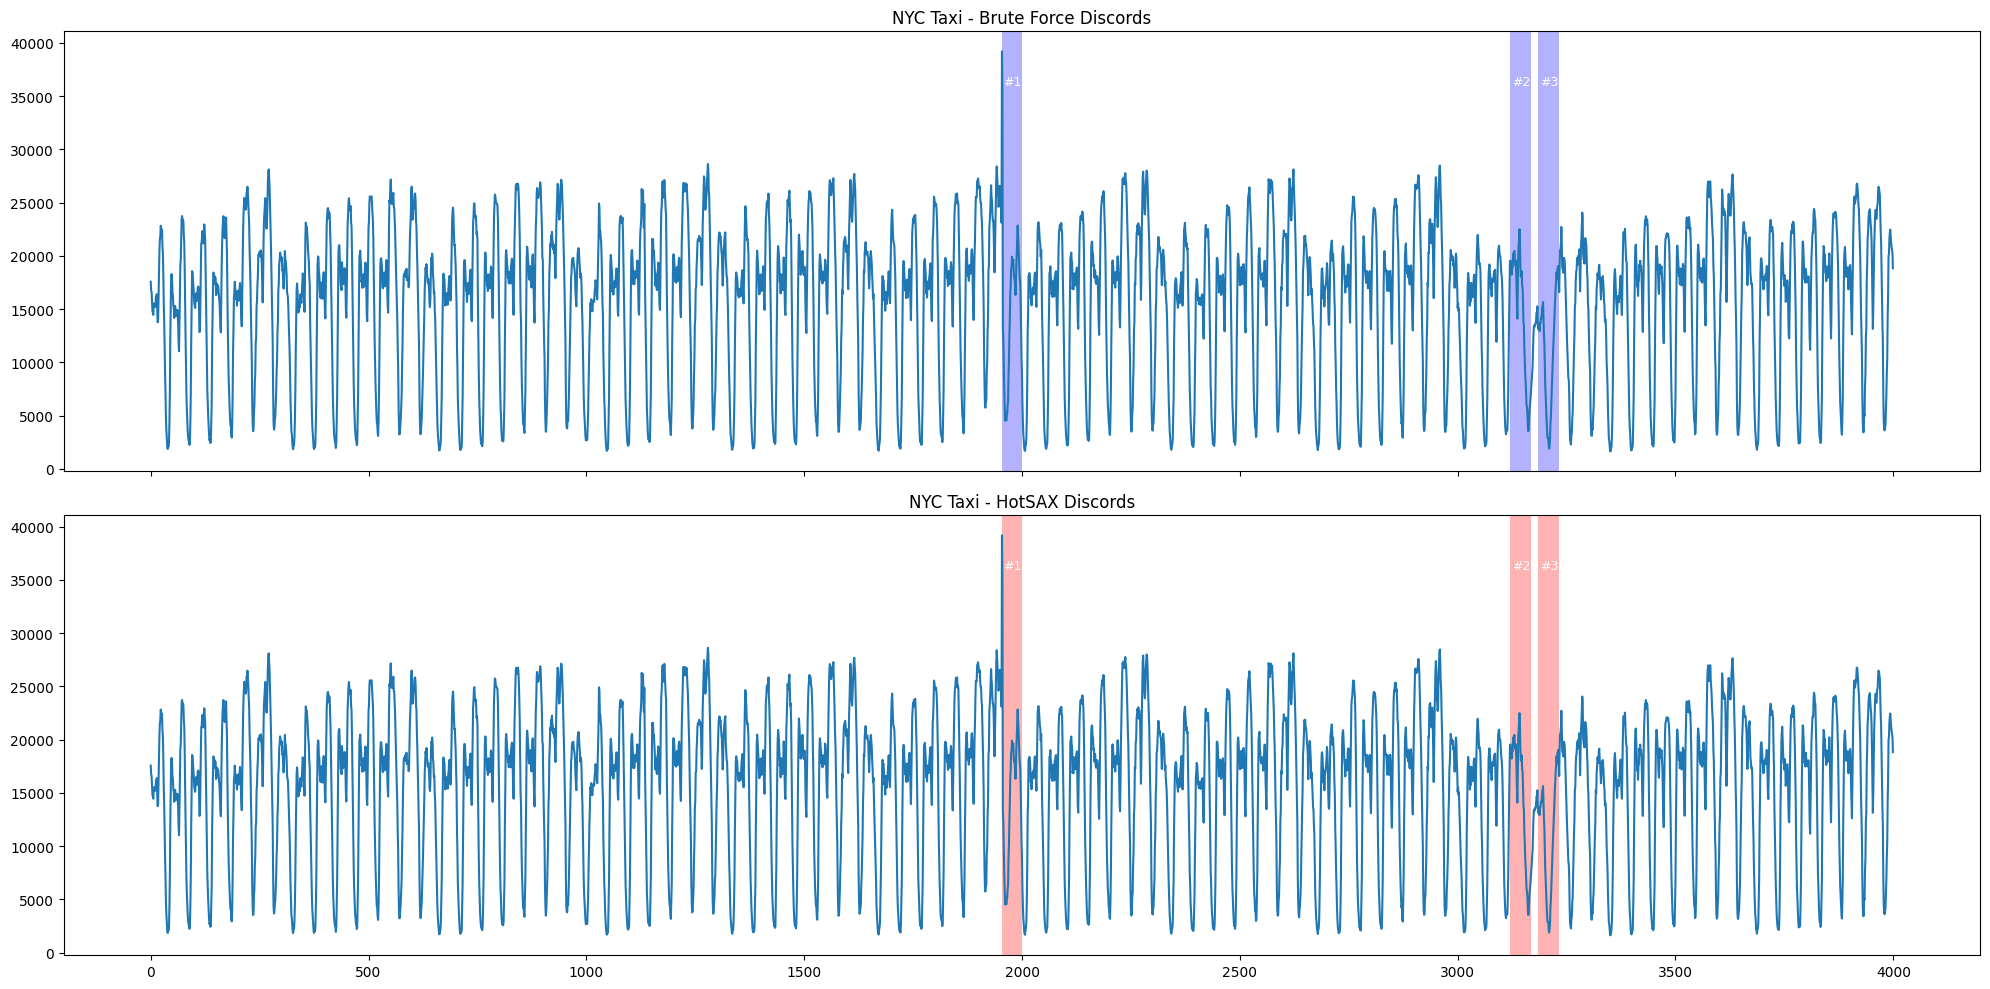

In [17]:

m_taxi = 48  # Длина окна (сутки)
k_taxi = 3   # Количество диссонансов

# --- Создаем новые словари для результатов по такси ---
times_taxi = {}
result_taxi = {}

# --- 1. HotSAX ---

print("Запускаю HotSAX для данных о такси...")
start_hotsax_taxi = time()
# Обрати внимание, передаем новый набор данных nyc_taxi и новые параметры
discords_hotsax_taxi = np.array(find_discords_hotsax(nyc_taxi, win_size=m_taxi, num_discords=k_taxi))
end_hotsax_taxi = time()

times_taxi['hotsax'] = end_hotsax_taxi - start_hotsax_taxi
result_taxi['hotsax'] = discords_hotsax_taxi

print(f"HotSAX занял: {times_taxi['hotsax']:.2f} секунд")
print("Найденные диссонансы (HotSAX):")
print(result_taxi['hotsax'])

# --- 2. Brute Force (Полный перебор) ---


print("\nЗапускаю полный перебор для данных о такси... Это может занять много времени.")
start_brute_taxi = time()
discords_brute_taxi = np.stack(find_discords_brute_force(nyc_taxi, m_taxi, k_taxi))
end_brute_taxi = time()

times_taxi['brute_force'] = end_brute_taxi - start_brute_taxi
result_taxi['brute_force'] = discords_brute_taxi

print(f"Полный перебор занял: {times_taxi['brute_force']:.2f} секунд")
print("Найденные диссонансы (Brute Force):")
print(result_taxi['brute_force'])

# --- 3. Визуализация результатов ---
fig, axes = plt.subplots(2, 1, figsize=(20, 10), sharex=True)

# График для Brute Force
axes[0].plot(nyc_taxi)
axes[0].set_title('NYC Taxi - Brute Force Discords')
for i, idx in enumerate(result_taxi['brute_force'][:, 0].astype(int)):
    rect = Rectangle((idx, axes[0].get_ylim()[0]), m_taxi, axes[0].get_ylim()[1] - axes[0].get_ylim()[0], facecolor='blue', alpha=0.3)
    axes[0].add_patch(rect)
    axes[0].text(idx + m_taxi / 2, axes[0].get_ylim()[1] * 0.9, f"#{i+1}", ha='center', va='top', fontsize=9, color='white')

# График для HotSAX
axes[1].plot(nyc_taxi)
axes[1].set_title('NYC Taxi - HotSAX Discords')
for i, idx in enumerate(result_taxi['hotsax'][:, 0].astype(int)):
    rect = Rectangle((idx, axes[1].get_ylim()[0]), m_taxi, axes[1].get_ylim()[1] - axes[1].get_ylim()[0], facecolor='red', alpha=0.3)
    axes[1].add_patch(rect)
    axes[1].text(idx + m_taxi / 2, axes[1].get_ylim()[1] * 0.9, f"#{i+1}", ha='center', va='top', fontsize=9, color='white')

plt.tight_layout()
plt.show()

#### **3.2 Поиск диссонансов с помощью алгоритма DRAG**

In [19]:
!pip install stumpy==1.11.1


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import stumpy
from stumpy import core, config
from stumpy.scrump import _prescrump


Как мы помним из лекций:

**Диапазонный диссонанс** – подпоследовательность ряда, расстояние от которой до ее ближайшего соседа не ниже заданного порога. 

Основными параметрами при поисках диссонансов являются:
- $m$ - длина диссонанса
- $r$ - пороговое значение расстояния подпоследовательности ряда, до его ближайшего соседа


In [21]:
from modules.drag import find_candidates, DRAG


Для поиска диссонансов в данной части практической работы мы воспользуемся алгоритмом **DRAG (Discord Range Aware Gathering)**.
Для начала воспользуемся данным алгоритмом, чтобы найти диссонансы в наборе данных содержащем активность человека.

In [22]:
data = walk_run

Длину искомого диссонанса, как и для предыдущих алгоритмов, мы установим равно 50 точек.
Пороговое значение мы установим равным большим, чтобы узнать, как алгоритм отреагирует на большие значения данного параметра.

In [23]:
m = 50 
r = 10
idxs, _, _ = DRAG(data,m,r)
print(f'Колличество найденных диссонансов: {len(idxs)}')

Колличество найденных диссонансов: 0


Как вы можете видеть мы установили слишком большое пороговое значение, алгоритму не удалось выделить ни одного диссонанса. Попробуем уменьшить пороговое значение до 1, чтобы улучшить результат. 

In [24]:
m = 50 
r = 1
idxs, _, _ = DRAG(data, m, r)
print(f'Колличество найденных диссонансов: {len(idxs)}')

Колличество найденных диссонансов: 50


При такой комбинации параметров, улучшить ситуацию не получилось. Алгоритм выделил слишком большое количество диссонансов, часть которых является ложными диссонансами и не будут информативными для нас.

Произведите подобные эксперименты с набором данных такси NY. Постройте графики демонстрирующие найденные диссонансы. Пример Графика:
![second-graph](pics/fig_ex_2.png)

Длина окна (m): 48, Пороговое расстояние (r): 1761.03

DRAG нашел 0 диссонансов за 0.10 секунд.


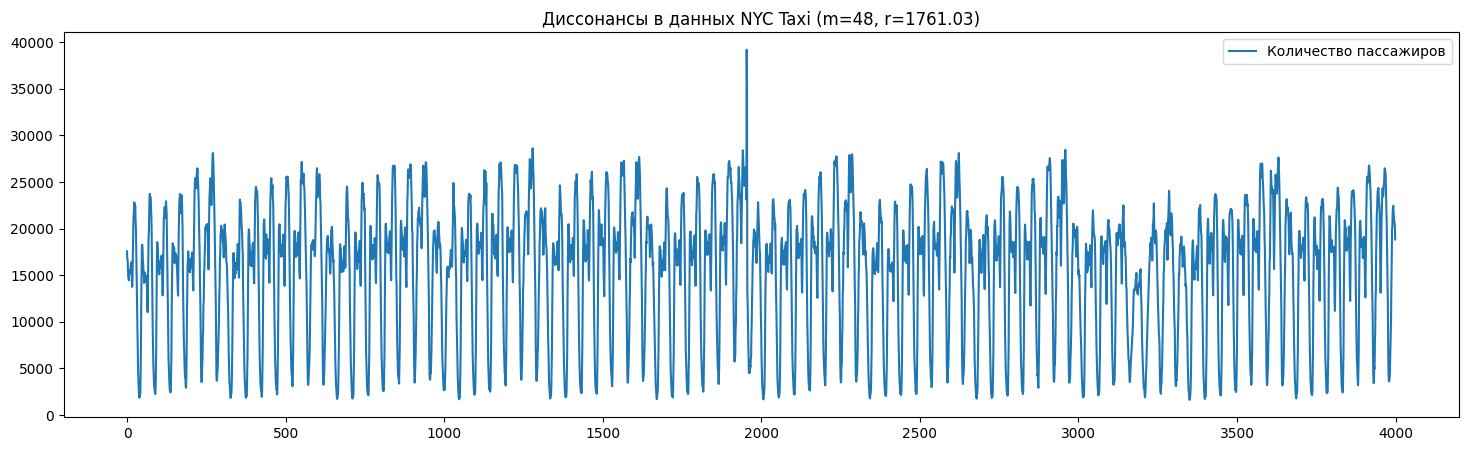

In [25]:
# Устанавливаем данные для анализа
data_taxi = nyc_taxi
m = 48

# Подбираем r. Возьмем 25% от стандартного отклонения данных.
# Это хороший эвристический подход для начала.
r = np.std(data_taxi) * 0.25 
print(f"Длина окна (m): {m}, Пороговое расстояние (r): {r:.2f}\n")

# Запускаем DRAG
start_drag = time()
idxs, _, _ = DRAG(data_taxi, m, r)
end_drag = time()

print(f"DRAG нашел {len(idxs)} диссонансов за {end_drag - start_drag:.2f} секунд.")

# --- Визуализация ---
fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(data_taxi, label='Количество пассажиров')
ax.set_title(f'Диссонансы в данных NYC Taxi (m={m}, r={r:.2f})')

# Отрисовка найденных диссонансов
for idx in idxs:
    rect = Rectangle((idx, ax.get_ylim()[0]), m, ax.get_ylim()[1] - ax.get_ylim()[0], facecolor='red', alpha=0.3)
    ax.add_patch(rect)

ax.legend()
plt.show()

Чтобы разобраться, почему так происходит и как работает данный алгоритм, ниже мы реализуем все этапы алгоритма DRAG.

Как мы помним из лекций алгоритм DRAG содержит два этапа:

1. Отбор - За одно сканирование ряда сформировать множество кандидатов в диссонансы.
2. Очистка - За одно сканирование ряда отбросить кандидатов, которые являются ложными диссонансами.

##### 3.2.1 Отбор кандидатов

Первым этапом обработки данных является отбор множества потенциальных кандидатов. Мы выбираем из всего множества подпоследовательностей ряда такие, для которых расстояние до правых ближайших соседей больше параметра $r$.

In [26]:
#выбирем более реальное значение для порога
r = 3

In [27]:
T, M_T, Σ_T = core.preprocess(data, m)
#формируем массив длинной равной длине  исходного ряда - m + 1, 
#элемент массива является истинным, 
#в том случае если подпоследовательность является потенциальным кандидатом
is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=None, right=True)
#находим индексы потенциальных кандидатов
cand_index = np.flatnonzero(is_cands)

In [28]:
print(f'{len(cand_index)} {len(cand_index)/len(data)*100} %')

109 10.9 %


Во время отбора кандидатов нам удалось выделить около 113 подпоследовательностей(около 11.3%), которые мы бы могли назвать потенциальными диссонансами.
Это большой процент, который не может нас устраивать как конечный результат.
Если посмотреть на рисунок ниже, мы увидим, что большая часть потенциальных диссонансов расположена в районе смены активности. 
К сожалению пресутсвуют и ложные диссонансы, которые случайным образом попали в данный список.

Сформируйте график найденных диссонансов

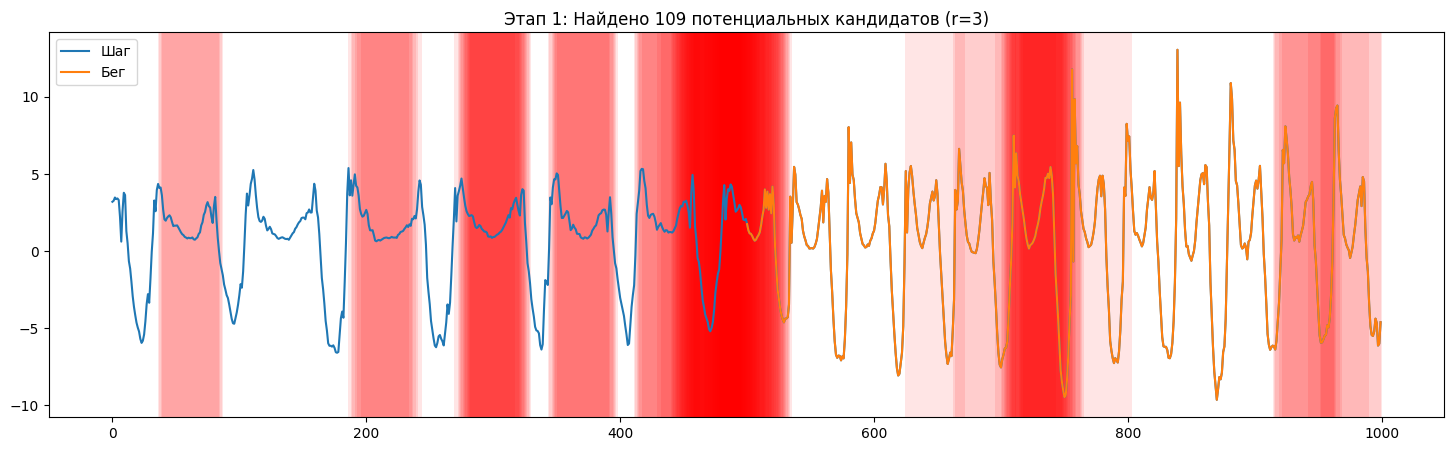

In [29]:
# График для кандидатов после первого прохода
fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(data, label='Шаг')
ax.plot(np.arange(data.shape[0]//2, data.shape[0]), data[data.shape[0]//2:], label='Бег')
ax.set_title(f'Этап 1: Найдено {len(cand_index)} потенциальных кандидатов (r={r})')

for idx in cand_index:
    rect = Rectangle((idx, ax.get_ylim()[0]), m, ax.get_ylim()[1] - ax.get_ylim()[0], facecolor='red', alpha=0.1)
    ax.add_patch(rect)

ax.legend()
plt.show()

##### 3.2.2 Очистка кандидатов
Как уже упоминалось выше, 11.3% слишком большой процент диссонансов.
Для уменьшения числа потенциальных кандидатов произведем очистку от ложных диссонансов, путем сравнения расстояния до левых ближайших соседей потенциальных диссонансов с порогом $r$.


In [30]:
is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=is_cands, right=False)
cands = np.flatnonzero(is_cands)

In [31]:
len(cands)/len(data)*100

2.3

Сформируйте график найденных диссонансов

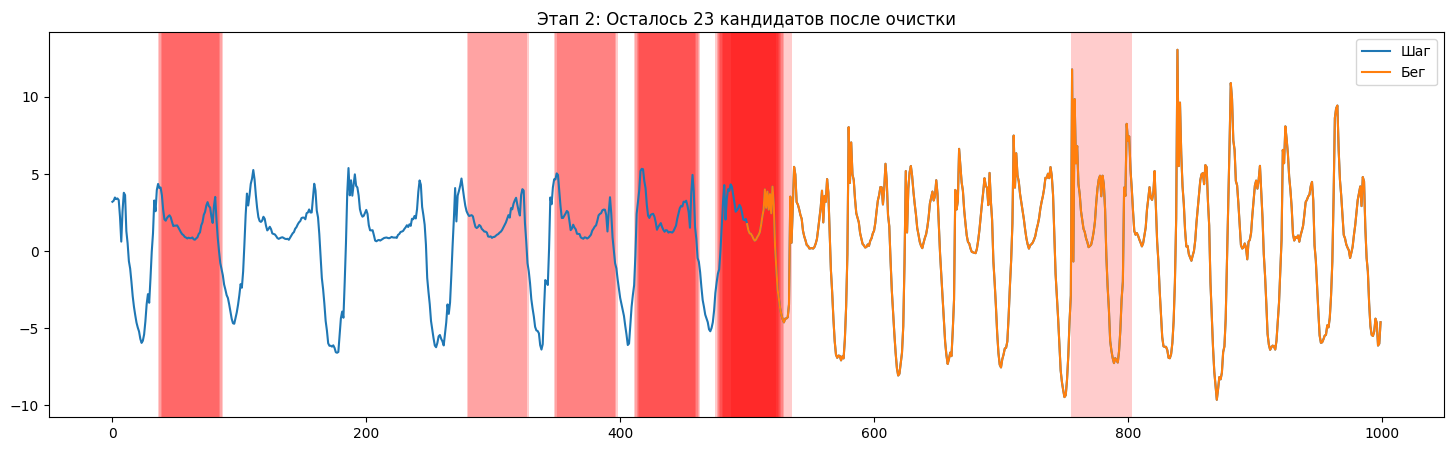

In [35]:
# График для кандидатов после второго прохода (очистки)
fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(data, label='Шаг')
ax.plot(np.arange(data.shape[0]//2, data.shape[0]), data[data.shape[0]//2:], label='Бег')
ax.set_title(f'Этап 2: Осталось {len(cands)} кандидатов после очистки')

for idx in cands:
    rect = Rectangle((idx, ax.get_ylim()[0]), m, ax.get_ylim()[1] - ax.get_ylim()[0], facecolor='red', alpha=0.2)
    ax.add_patch(rect)
    
ax.legend()
plt.show()

Нам удалось сократить число диссонансов до 2.9%. Если проанализировать рисунок, то можно заметить, что большая их часть является тривиальными повторениями подпоследовательности в области смены активности. На следующем шаге избавимся от них.

In [36]:
from modules.drag import refine_candidates
discords_idx, discords_dist, discords_nn_idx = refine_candidates(T, m, M_T, Σ_T, is_cands)
len(discords_idx)/len(data)*100

0.6

Сформируйте график найденных диссонансов

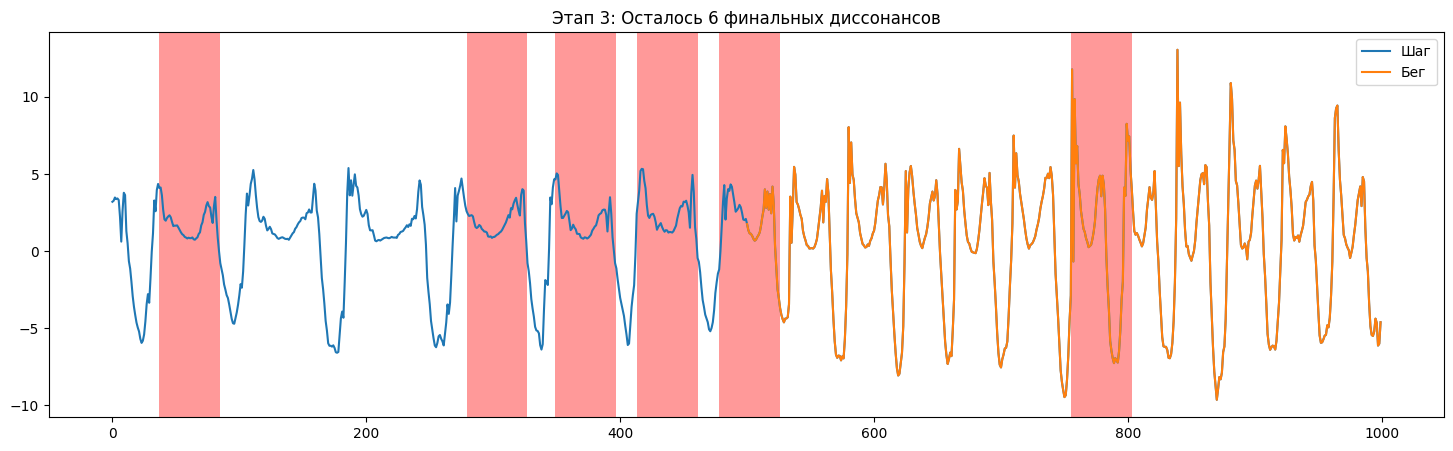

In [37]:
# График для финальных диссонансов
fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(data, label='Шаг')
ax.plot(np.arange(data.shape[0]//2, data.shape[0]), data[data.shape[0]//2:], label='Бег')
ax.set_title(f'Этап 3: Осталось {len(discords_idx)} финальных диссонансов')

for idx in discords_idx:
    rect = Rectangle((idx, ax.get_ylim()[0]), m, ax.get_ylim()[1] - ax.get_ylim()[0], facecolor='red', alpha=0.4)
    ax.add_patch(rect)
    
ax.legend()
plt.show()

##### 3.2.3 Подбор параметров

Реализуйте перебор параметров $m$ и $r$. Подберете параметры таким образом, чтобы алгоритм обнаружил только те диссонансы, которые связаны со сменой активности. Сделайте вывод о том, как эти параметры влияют на качество работы модели.
Подберите оптимальные параметры алгоритма для набора данных такси NY. 
Визуализируйте результаты для разных комбинаций. Сделайте выводы.


--- Эксперименты с данными walk_run ---


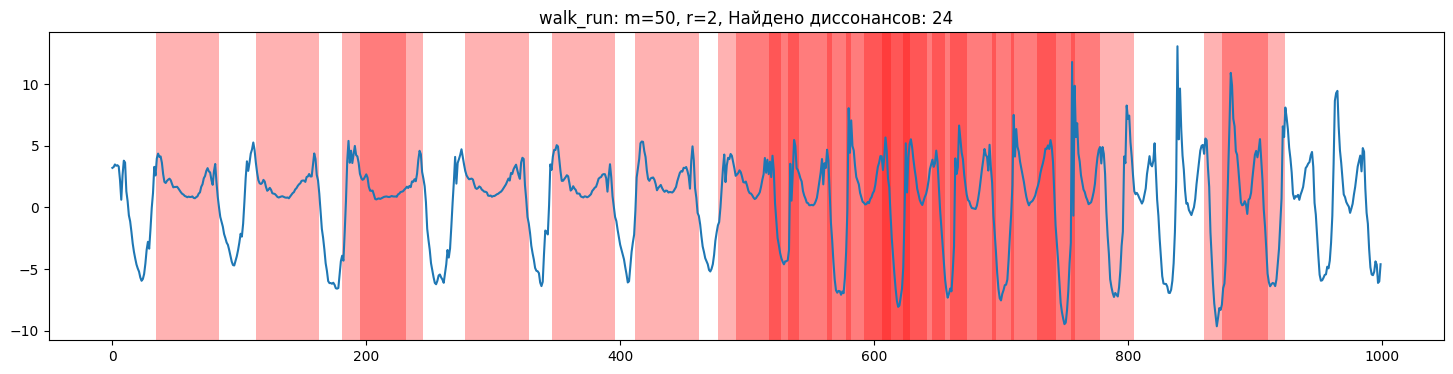

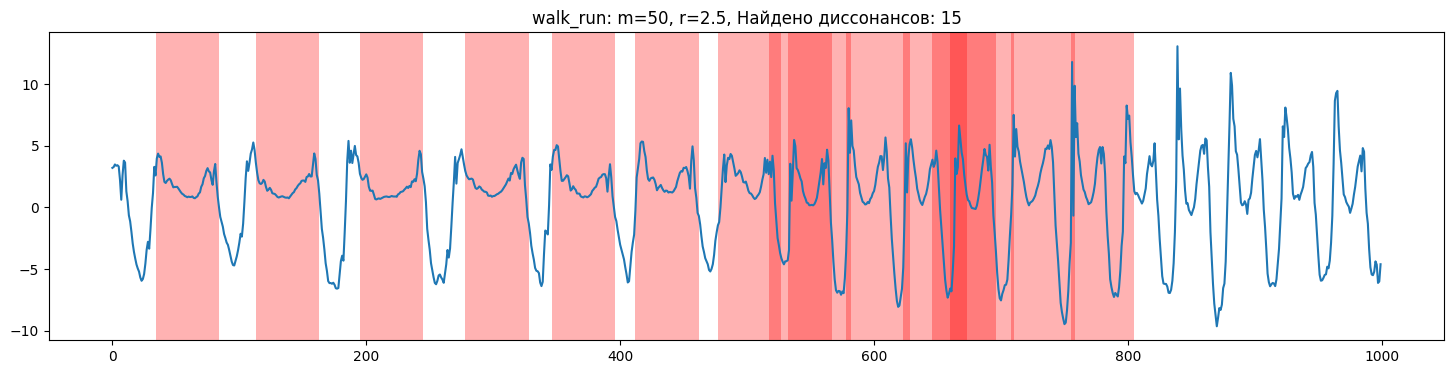

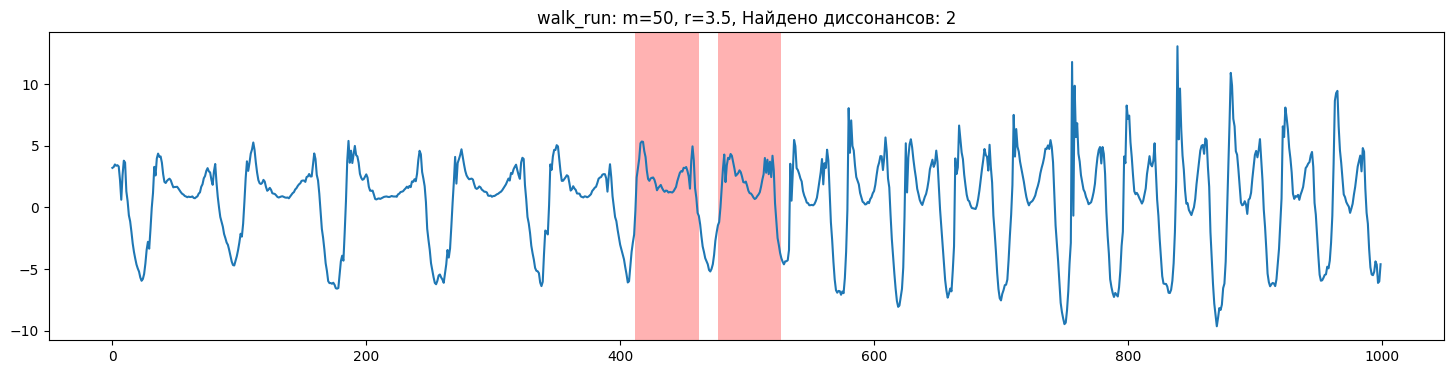

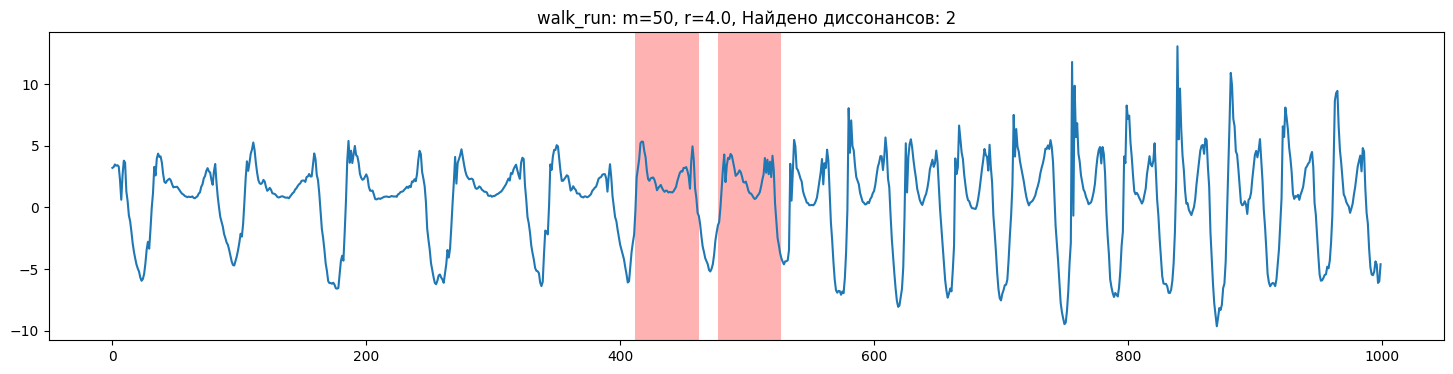


--- Эксперименты с данными nyc_taxi ---


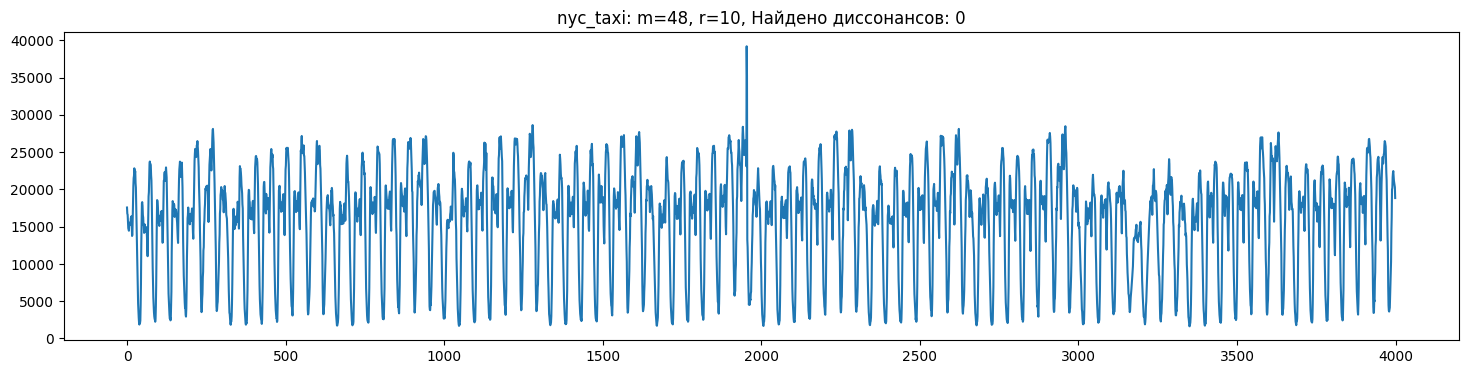

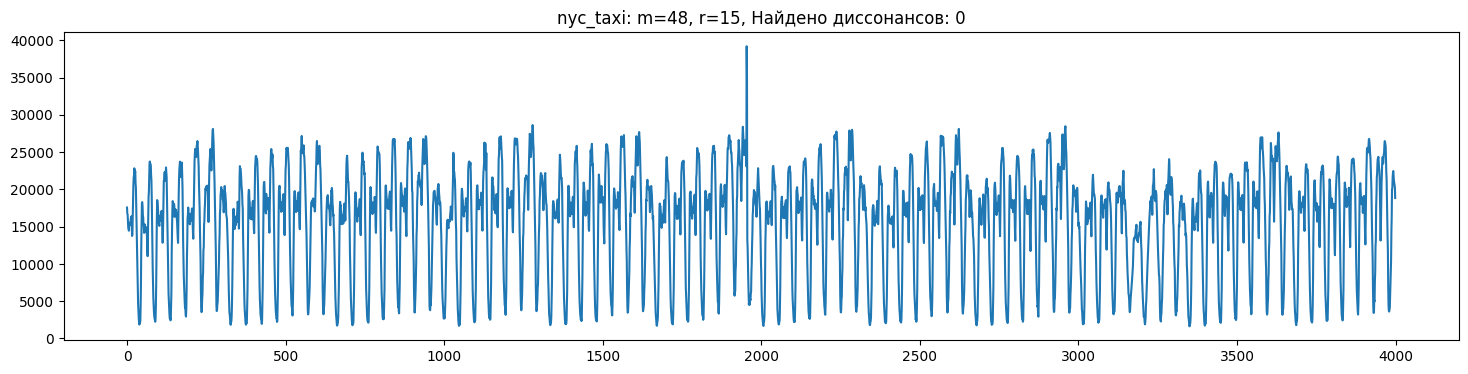

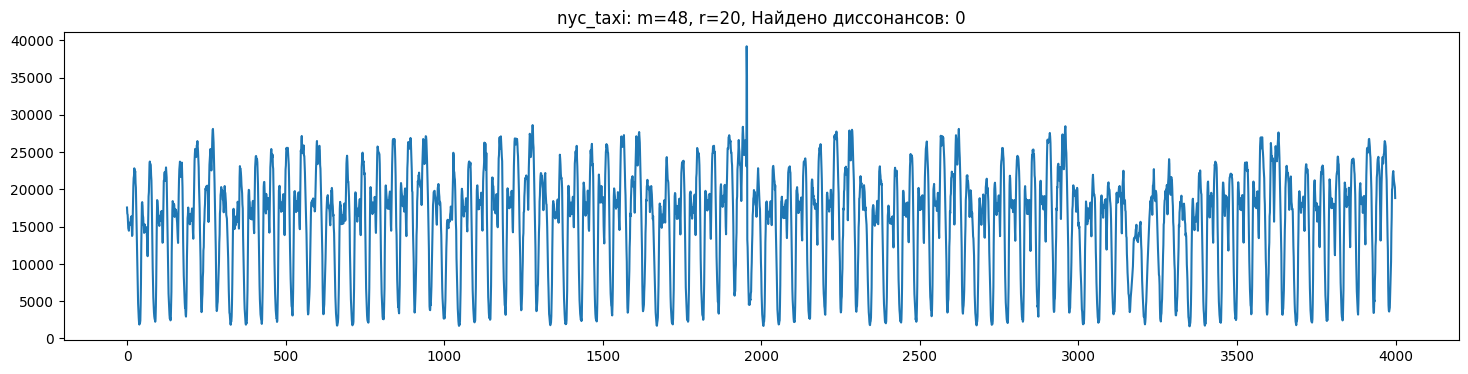

In [38]:
# --- Эксперименты с данными walk_run ---
print("--- Эксперименты с данными walk_run ---")
data_walk_run = walk_run
m_walk_run = 50
# Список значений r для эксперимента. Мы хотим найти тот, что выделит только переходную зону.
r_values_walk = [2, 2.5, 3.5, 4.0] 

for r_val in r_values_walk:
    idxs, _, _ = DRAG(data_walk_run, m_walk_run, r_val)
    
    fig, ax = plt.subplots(figsize=(18, 4))
    ax.plot(data_walk_run, label='Шаг/Бег')
    ax.set_title(f'walk_run: m={m_walk_run}, r={r_val}, Найдено диссонансов: {len(idxs)}')
    for idx in idxs:
        rect = Rectangle((idx, ax.get_ylim()[0]), m_walk_run, ax.get_ylim()[1] - ax.get_ylim()[0], facecolor='red', alpha=0.3)
        ax.add_patch(rect)
    plt.show()

# --- Эксперименты с данными nyc_taxi ---
print("\n--- Эксперименты с данными nyc_taxi ---")
data_taxi = nyc_taxi
m_taxi = 48
# Список значений r для эксперимента. Ищем значимые аномалии (праздники, события).
r_values_taxi = [10, 15, 20] 

for r_val in r_values_taxi:
    idxs, _, _ = DRAG(data_taxi, m_taxi, r_val)
    
    fig, ax = plt.subplots(figsize=(18, 4))
    ax.plot(data_taxi)
    ax.set_title(f'nyc_taxi: m={m_taxi}, r={r_val}, Найдено диссонансов: {len(idxs)}')
    for idx in idxs:
        rect = Rectangle((idx, ax.get_ylim()[0]), m_taxi, ax.get_ylim()[1] - ax.get_ylim()[0], facecolor='red', alpha=0.3)
        ax.add_patch(rect)
    plt.show()

# --- Создай новую ячейку (Markdown) и напиши там свои выводы ---

#### **3.3 Поиск диссонансов с помощью алгоритма Merlin**

Как мы уже выяснили подбирать параметры для DRAG простым перебором не очень удобно. Для оптимизации данного процесса в статье [1] был предложен алгоритм Merlin для оптимального поиска подходящего порогового значения.

Условно мы можем разделить поиск диссонансов на три шага:

1. Поиск диссонансов минимальной длинны $minL$. На данном шаге $r = 2\sqrt{minL}$.
2. Поиск диссонансов следующих четырех длин. На данном шаге $r = 0.99 \cdot nndist_{m-1}$. Где $nndist_{m-1}$ - расстояние до ближайшего соседа предыдущего найденного диссонанса.
3. Поиск диссонансов всех 
оставшихся дли. $r = \mu - 2 \sigma$. Средние значение и стандартное отклонение вычисляются из расстояний 5 предыдущих диссонансов. н

[1] Nakamura T., Imamura M., Mercer R., Keogh E.J. MERLIN: parameter-free discovery of arbitrary length anomalies in massive time series archives. 20th IEEE Int. Conf. on Data Mining, ICDM 2020, Sorrento, Italy, November 17-20, 2020. pp. 1190-1195. IEEE (2020). https://doi.org/10.1109/ICDM50108.2020.00147

##### 3.3.1 Поиск диссонансов минимальной длинны

Вспомнил последовательность действий первого шага алгоритма:
![merlin-part-first](pics/first_part.png)

В данной работе мы внесем небольшое изменение, мы будем считать, что подпоследовательность может быть диссонансом только в том случае, если больше 75% точек, не входят в состав других диссонансов. 

In [39]:
T = walk_run
m = 50
# сформируем массив метод для потенциальных кандидатов в диссонансы.
# после каждого найденного диссонанса, 
# мы будем исключать окружающие его подпоследовательности из числа потенциальных кандидатов,
# путем замены значений их меток на false
excl_zone = int(np.ceil(m / 4))
include = np.ones(len(T)-m+1, dtype=bool)
# Количество диссонансов, которые мы будем искать
topK = 10


In [40]:
dis_idx = -np.ones((topK))
dis_nnDist = -np.ones((topK))
dis_nn_idx = np.full((topK),-np.inf)
#первое прближение r
r = 2*np.sqrt(m)
minL = m
maxL = int(m+np.ceil(m*0.1))
#количество найденных диссонасов
cound_find_dis = 0

while dis_nnDist[cound_find_dis-1]<0 and cound_find_dis<topK:
    result = DRAG(data=T,m=minL,r=r, include =include)
    for diss, nnDist, nn in zip(*result):
        dis_idx[cound_find_dis] = diss
        dis_nnDist[cound_find_dis] = nnDist
        dis_nn_idx[cound_find_dis] = nn
        #исключаем окружающие найденный диссонас 
        #подпоследовательности и числа потенциальных диссонасов
        core.apply_exclusion_zone(include, diss, excl_zone, False)
        cound_find_dis+=1
        if cound_find_dis>=topK:
            break
    r*=0.5

In [41]:
maxL

55

In [42]:
print('Количество найденных на первом этапе диссонансов:', cound_find_dis)

Количество найденных на первом этапе диссонансов: 2


На первом шаге нам удалось выделить 2 диссонанса из 10 требуемых. 
Реализуйте, оставшиеся шаги алгоритма, чтобы найти оставшиеся диссонансы. 

![merlin-part-first](pics/second_part.png)


In [43]:

# (i от minL + 1 до minL + 4)
for i in range(minL + 1, minL + 5):
    if cound_find_dis >= topK:
        break
    
    # Инициализируем расстояние для текущей длины
    dis_nnDist_i = -1
    
    # Рассчитываем r на основе предыдущего найденного диссонанса
    r = 0.99 * dis_nnDist[cound_find_dis - 1]
    
    while dis_nnDist_i < 0 and cound_find_dis < topK:
        result = DRAG(data=T, m=i, r=r, include=include)
        
        # Если DRAG нашел диссонансы
        if len(result[0]) > 0:
            # Берем самый сильный диссонанс (он всегда первый в результате refine_candidates)
            diss, nnDist, nn = result[0][0], result[1][0], result[2][0]
            
            dis_idx[cound_find_dis] = diss
            dis_nnDist[cound_find_dis] = nnDist
            dis_nnDist_i = nnDist # Сохраняем для while-цикла
            dis_nn_idx[cound_find_dis] = nn
            
            core.apply_exclusion_zone(include, diss, int(np.ceil(i / 4)), False)
            cound_find_dis += 1
        
        # Уменьшаем r, если ничего не нашли
        r *= 0.99

# --- Шаг 3: Поиск для оставшихся длин ---
# (i от minL + 5 до maxL)
for i in range(minL + 5, maxL + 1):
    if cound_find_dis >= topK:
        break
    
    # Вычисляем среднее и стд. отклонение по последним 5 найденным диссонансам
    mu = np.mean(dis_nnDist[cound_find_dis-5 : cound_find_dis])
    sigma = np.std(dis_nnDist[cound_find_dis-5 : cound_find_dis])
    
    # Рассчитываем r
    r = mu - 2 * sigma
    
    # Инициализируем расстояние для текущей длины
    dis_nnDist_i = -1

    while dis_nnDist_i < 0 and cound_find_dis < topK:
        result = DRAG(data=T, m=i, r=r, include=include)
        
        # Если DRAG нашел диссонансы
        if len(result[0]) > 0:
            diss, nnDist, nn = result[0][0], result[1][0], result[2][0]

            dis_idx[cound_find_dis] = diss
            dis_nnDist[cound_find_dis] = nnDist
            dis_nnDist_i = nnDist
            dis_nn_idx[cound_find_dis] = nn

            core.apply_exclusion_zone(include, diss, int(np.ceil(i / 4)), False)
            cound_find_dis += 1

        # Уменьшаем r, если ничего не нашли
        r -= sigma

print(f"Итого найдено диссонансов: {cound_find_dis}")
print("Индексы найденных диссонансов:")
# Выводим только те, что были найдены
print(dis_idx[:cound_find_dis].astype(int))

Итого найдено диссонансов: 7
Индексы найденных диссонансов:
[477 412 195 575  31 755 623]


Найдите диссонансы набора такси NY. Визуализируйте найденные диссонансы для обоих наборов данных, сравните с результатами остальных методов. 


--- Результаты Merlin для walk_run ---


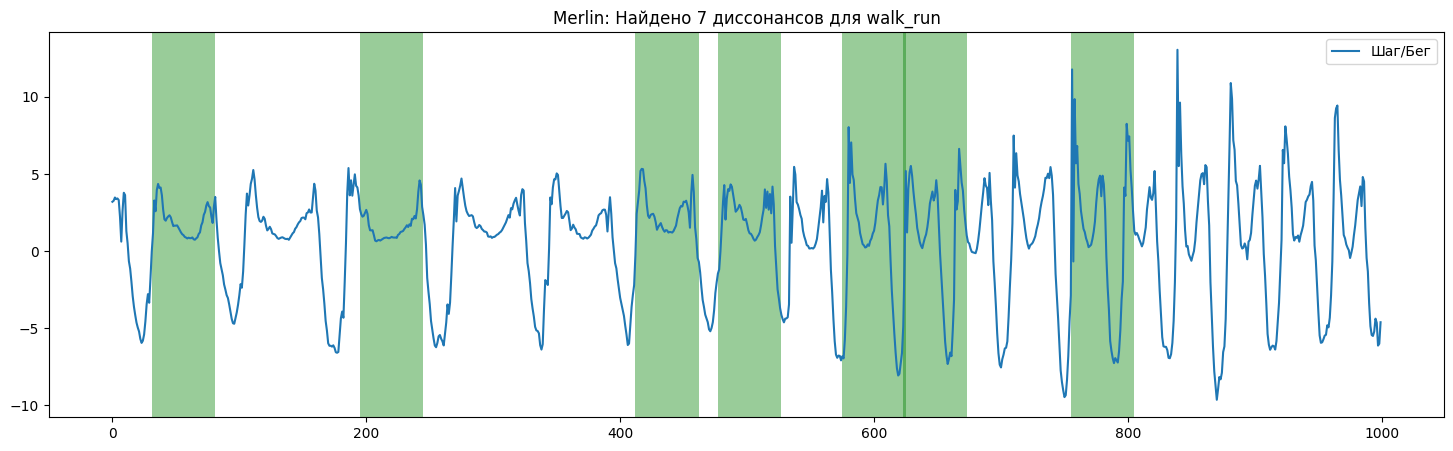


--- Применение Merlin к данным nyc_taxi ---
Итого найдено диссонансов для nyc_taxi: 3


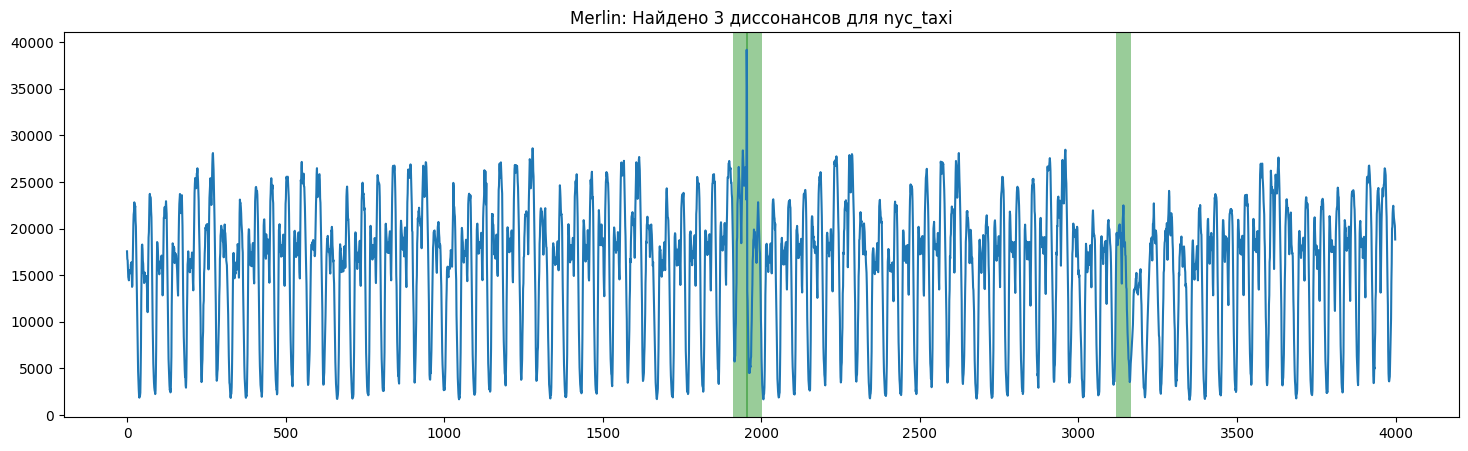

In [44]:
# --- 1. Визуализация для walk_run ---
print("--- Результаты Merlin для walk_run ---")
fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(data, label='Шаг/Бег')
ax.set_title(f'Merlin: Найдено {cound_find_dis} диссонансов для walk_run')

# Отображаем диссонансы, которые были найдены
final_discords_walk_run = dis_idx[:cound_find_dis].astype(int)
for idx in final_discords_walk_run:
    # Длина окна m может меняться, но для визуализации используем базовую minL
    rect = Rectangle((idx, ax.get_ylim()[0]), minL, ax.get_ylim()[1] - ax.get_ylim()[0], facecolor='green', alpha=0.4)
    ax.add_patch(rect)
    
ax.legend()
plt.show()

# --- 2. Применение Merlin к nyc_taxi ---
print("\n--- Применение Merlin к данным nyc_taxi ---")
T_taxi = nyc_taxi
m_taxi = 48 # Минимальная длина диссонанса
topK_taxi = 5 # Ищем 5 диссонансов
excl_zone_taxi = int(np.ceil(m_taxi / 4))
include_taxi = np.ones(len(T_taxi) - m_taxi + 1, dtype=bool)

dis_idx_taxi = -np.ones(topK_taxi)
dis_nnDist_taxi = -np.ones(topK_taxi)
cound_find_dis_taxi = 0
maxL_taxi = int(m_taxi + np.ceil(m_taxi * 0.1))


# Шаг 1 для такси
r_taxi = 2 * np.sqrt(m_taxi)
while dis_nnDist_taxi[cound_find_dis_taxi - 1] < 0 and cound_find_dis_taxi < topK_taxi:
    result_taxi_merlin = DRAG(data=T_taxi, m=m_taxi, r=r_taxi, include=include_taxi)
    if len(result_taxi_merlin[0]) > 0:
        for diss, nnDist, nn in zip(*result_taxi_merlin):
            dis_idx_taxi[cound_find_dis_taxi] = diss
            dis_nnDist_taxi[cound_find_dis_taxi] = nnDist
            core.apply_exclusion_zone(include_taxi, diss, excl_zone_taxi, False)
            cound_find_dis_taxi += 1
            if cound_find_dis_taxi >= topK_taxi: break
    if cound_find_dis_taxi == 0:
         r_taxi *= 0.5
    else:
        break # Выходим, если хоть один диссонанс найден

# Шаги 2 и 3 для такси (объединены для простоты)
if cound_find_dis_taxi > 0 and cound_find_dis_taxi < topK_taxi:
    # Будем использовать упрощенный подход: r = 0.99 * nnDist предыдущего
    for i in range(m_taxi + 1, maxL_taxi + 5): # Ищем для нескольких следующих длин
        if cound_find_dis_taxi >= topK_taxi: break
        
        r_taxi = 0.99 * dis_nnDist_taxi[cound_find_dis_taxi - 1]
        result_taxi_merlin = DRAG(data=T_taxi, m=i, r=r_taxi, include=include_taxi)
        
        if len(result_taxi_merlin[0]) > 0:
            diss, nnDist, nn = result_taxi_merlin[0][0], result_taxi_merlin[1][0], result_taxi_merlin[2][0]
            dis_idx_taxi[cound_find_dis_taxi] = diss
            dis_nnDist_taxi[cound_find_dis_taxi] = nnDist
            core.apply_exclusion_zone(include_taxi, diss, int(np.ceil(i/4)), False)
            cound_find_dis_taxi += 1

print(f"Итого найдено диссонансов для nyc_taxi: {cound_find_dis_taxi}")

# Визуализация для такси
fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(T_taxi)
ax.set_title(f'Merlin: Найдено {cound_find_dis_taxi} диссонансов для nyc_taxi')

final_discords_taxi = dis_idx_taxi[:cound_find_dis_taxi].astype(int)
for idx in final_discords_taxi:
    rect = Rectangle((idx, ax.get_ylim()[0]), m_taxi, ax.get_ylim()[1] - ax.get_ylim()[0], facecolor='green', alpha=0.4)
    ax.add_patch(rect)
plt.show()